# 🎯 Этап 3: Анализ ошибок и Инференс (Evaluation & Inference)

**Цель:** Проанализировать матрицу ошибок (Confusion Matrix) для понимания сильных и слабых сторон модели, а также визуализировать работу обученной нейросети (YOLOv8m) на валидационных данных. Соответствует разделу 8.6 проектного практикума.

In [1]:
import os
import glob
import random
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

plt.rcParams['figure.figsize'] = (12, 8)
print("[INFO] Библиотеки загружены, готовы к инференсу!")

[INFO] Библиотеки загружены, готовы к инференсу!


## 1. Анализ матрицы ошибок (Confusion Matrix)
Матрица ошибок показывает, как часто модель путает классы между собой и с фоном (background). Это критически важно для понимания ограничений системы.

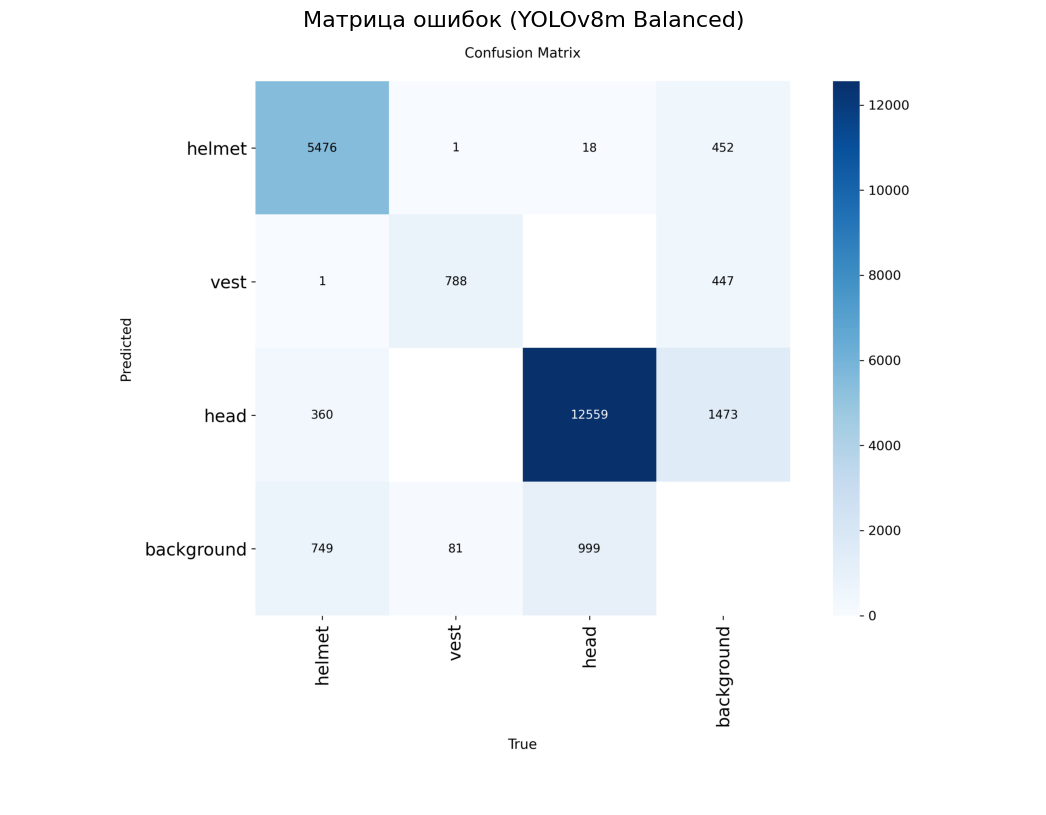

In [2]:
cm_path = r"C:\Practicum\results\logs\yolov8m_balanced-3\confusion_matrix.png"

if os.path.exists(cm_path):
    img_cm = Image.open(cm_path)
    plt.figure(figsize=(14, 10))
    plt.imshow(img_cm)
    plt.axis('off')
    plt.title("Матрица ошибок (YOLOv8m Balanced)", fontsize=16)
    plt.show()
else:
    print(f"[ERROR] Матрица не найдена по пути: {cm_path}")

## 2. Визуализация предсказаний (Inference)
Загрузим лучшие веса нашей модели и протестируем её работу на случайном изображении из валидационной выборки, которое она не видела в процессе обучения.

[INFO] Загрузка модели...
[INFO] Делаем предсказание для: pos_767.jpg


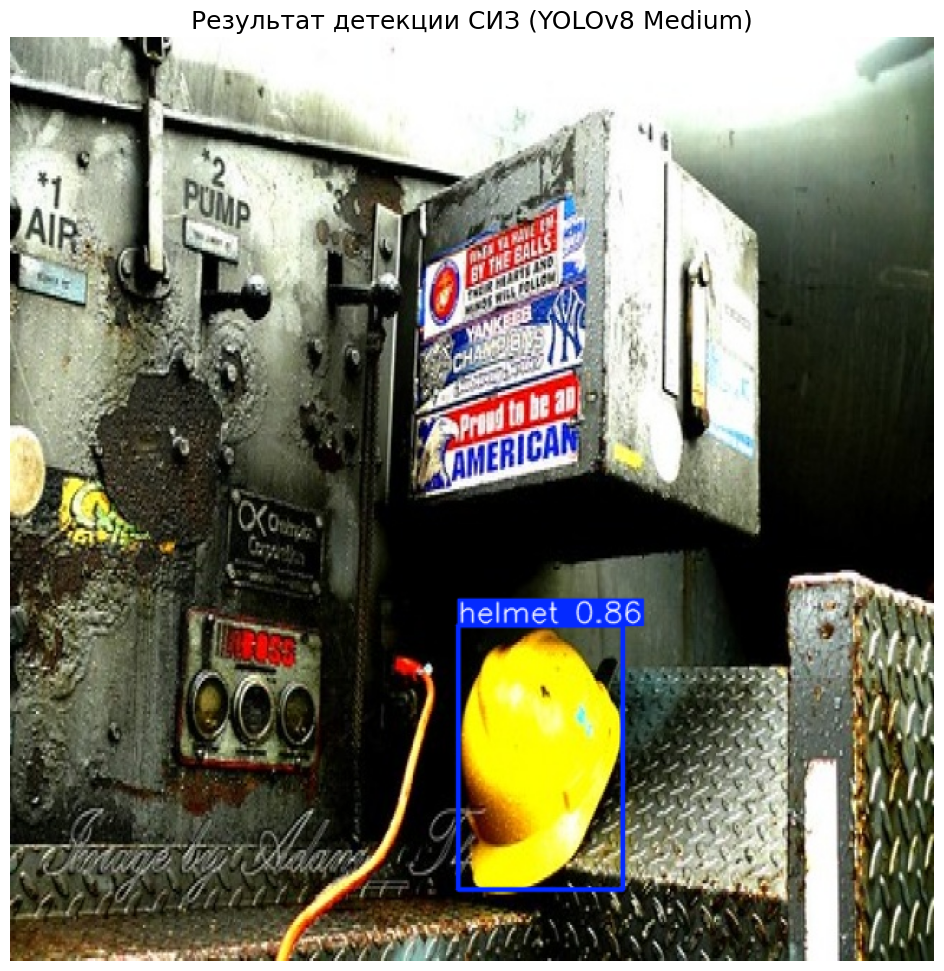

In [3]:
model_path = r"C:\Practicum\src\models\yolov8m_trained_balanced_30.pt"

val_images_dir = r"C:\Practicum\data\processed\images\val"

if os.path.exists(model_path) and os.path.exists(val_images_dir):
    print("[INFO] Загрузка модели...")
    model = YOLO(model_path)

    all_val_imgs = glob.glob(os.path.join(val_images_dir, "*.jpg"))
    test_img = random.choice(all_val_imgs)
    print(f"[INFO] Делаем предсказание для: {os.path.basename(test_img)}")

    results = model.predict(source=test_img, conf=0.5, save=False, verbose=False)

    annotated_frame = results[0].plot()

    annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(16, 12))
    plt.imshow(annotated_frame)
    plt.axis('off')
    plt.title("Результат детекции СИЗ (YOLOv8 Medium)", fontsize=18)
    plt.show()
else:
    print("[ERROR] Проверь пути к модели или валидационной папке!")